🎬 Memulai Pelatihan RL: World Agent Multi-Trace Mode
✅ Berhasil memuat 8 file trace dari folder 'traces/mahimahi'.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -283     |
| time/              |          |
|    fps             | 4723     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -225        |
| time/                   |             |
|    fps                  | 3355        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.0

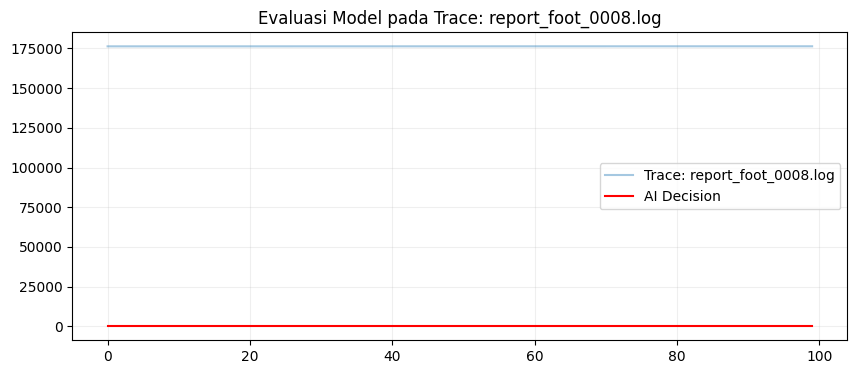

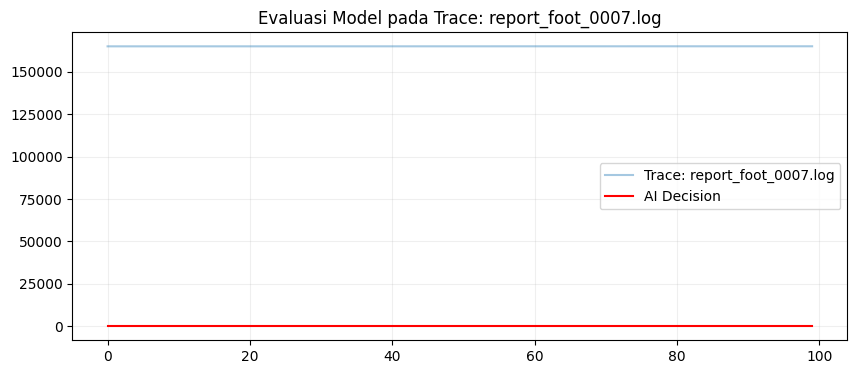

In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
import os
import random

class MahimahiTraceManager:
    """
    Mengelola banyak file bandwidth dari sebuah folder.
    Sistem akan memilih satu trace secara acak setiap kali episode di-reset.
    """
    def __init__(self, folder_path="traces_folder"):
        self.traces = []
        
        # Cek folder dan muat semua file .txt
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.endswith('.log')]
            for file in files:
                path = os.path.join(folder_path, file)
                try:
                    with open(path, 'r') as f:
                        # Mahimahi format: throughput dalam baris (asumsi Mbps atau dikonversi)
                        data = [float(line.strip()) for line in f if line.strip()]
                        if data:
                            self.traces.append({
                                "name": file,
                                "data": data
                            })
                except Exception as e:
                    print(f"⚠️ Gagal membaca {file}: {e}")
            
            if self.traces:
                print(f"✅ Berhasil memuat {len(self.traces)} file trace dari folder '{folder_path}'.")
        
        # Jika folder kosong/tidak ada, gunakan data sintetis sebagai cadangan agar kode tidak crash
        if not self.traces:
            print("⚠️ Folder trace kosong atau tidak ditemukan. Menggunakan pola sintetis...")
            self.traces.append({
                "name": "synth_volatile",
                "data": np.clip(10 + 5 * np.sin(np.linspace(0, 50, 1000)) + np.random.normal(0, 2, 1000), 0.5, 20).tolist()
            })

        self.active_trace = None
        self.ptr = 0

    def select_random_trace(self):
        """Memilih satu trace secara acak untuk sesi latihan ini"""
        self.active_trace = random.choice(self.traces)
        # Mulai dari titik acak di dalam trace agar variasi lebih tinggi
        self.ptr = random.randint(0, max(0, len(self.active_trace["data"]) - 105))
        return self.active_trace["name"]

    def get_next_bandwidth(self):
        if not self.active_trace:
            self.select_random_trace()
        
        val = self.active_trace["data"][self.ptr]
        self.ptr = (self.ptr + 1) % len(self.active_trace["data"])
        return val

class TandonMahimahiEnv(gym.Env):
    """
    World Agent (Lingkungan) berbasis Multi-Trace Mahimahi.
    Logic: Operator Tandon Air (Safety First).
    """
    def __init__(self, trace_manager):
        super(TandonMahimahiEnv, self).__init__()
        self.trace_manager = trace_manager
        self.bitrates = [0.5, 2.5, 8.0] # Mbps
        
        # State Space (7 Variabel sesuai Fase 1 & 2):
        # [Buffer, Throughput, LastAction, Buffer_Trend, TP_Trend, RTT, Dropped]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, -5, -5, 0, 0]),
            high=np.array([30, 20, 2, 5, 5, 1000, 100]),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)
        
        self.state = None
        self.max_steps = 100
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Setiap reset, ganti trace untuk generalisasi
        trace_name = self.trace_manager.select_random_trace()
        initial_tp = self.trace_manager.get_next_bandwidth()
        
        # Start state: Buffer 15s, TP dari trace, LastAction Mid, Trends 0, RTT 40ms, Dropped 0
        self.state = np.array([15.0, initial_tp, 1.0, 0.0, 0.0, 40.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {"trace": trace_name}

    def step(self, action):
        buffer, last_tp_avg, last_action, _, _, rtt, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        # Ambil kondisi internet nyata dari trace Mahimahi
        raw_tp = self.trace_manager.get_next_bandwidth()
        
        # Simulasi Tandon
        seg_duration = 5.0
        # Waktu download dipengaruhi oleh RTT NDN dan bandwidth trace
        download_time = (chosen_bitrate * seg_duration / (raw_tp + 0.1)) + (rtt / 1000.0)
        stalling = max(0, download_time - buffer)
        
        # Update Buffer Level
        new_buffer = max(0, buffer - download_time) + seg_duration
        new_buffer = min(new_buffer, 30.0)
        
        # Hitung Tren (Sangat penting bagi kecerdasan agen)
        buf_trend = np.clip(new_buffer - buffer, -5, 5)
        tp_trend = np.clip(raw_tp - last_tp_avg, -5, 5)
        
        # --- LOGIKA REWARD (Tandon Air) ---
        reward = chosen_bitrate * 1.0 # Reward kualitas
        reward -= abs(action - last_action) * 0.8 # Penalti switching (Visual smoothness)
        
        if stalling > 0:
            reward -= 100.0 # Penalti macet sangat berat
        
        if new_buffer < 10.0 and action == 2:
            reward -= 40.0 # Penalti risiko (Darurat)
            
        if action == 0 and raw_tp > 12.0 and new_buffer > 20.0:
            reward -= 20.0 # Penalti "Pelit" (Internet kencang tapi pilih Low)

        # Update State
        self.state = np.array([new_buffer, raw_tp, float(action), buf_trend, tp_trend, 40.0, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {"raw_tp": raw_tp}

def run_multi_trace_training():
    print("🎬 Memulai Pelatihan RL: World Agent Multi-Trace Mode")
    
    # Inisialisasi Trace Manager dengan folder 'traces_folder'
    tm = MahimahiTraceManager(folder_path="traces/mahimahi") 
    env = TandonMahimahiEnv(tm)
    
    # Konfigurasi PPO untuk stabilitas tinggi
    model = PPO("MlpPolicy", env, verbose=1, 
                learning_rate=0.00025, 
                n_steps=1024,
                ent_coef=0.01)
    
    # Latih selama 150.000 timesteps untuk mencakup variasi semua file trace
    model.learn(total_timesteps=150000)
    model.save("ndn_video_brain_tandon_multi_trace")
    print("✅ Pelatihan Selesai. Model 'ndn_video_brain_tandon_multi_trace.zip' telah dibuat.")

    # --- EVALUASI PADA TRACE ACAK ---
    for i in range(2):
        obs, info = env.reset()
        name = info["trace"]
        history = []
        for _ in range(100):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info_step = env.step(action)
            history.append({'S': info_step['raw_tp'], 'B': obs[0], 'A': action})
        
        df = pd.DataFrame(history)
        plt.figure(figsize=(10, 4))
        plt.plot(df.index, df['S'], label=f'Trace: {name}', alpha=0.4)
        plt.step(df.index, df['A']*4 + 2, label='AI Decision', color='red')
        plt.title(f"Evaluasi Model pada Trace: {name}")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

if __name__ == "__main__":
    run_multi_trace_training()